Files already downloaded and verified
Files already downloaded and verified


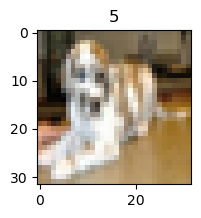

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1             [1, 6, 30, 30]             168
         MaxPool2d-2             [1, 6, 15, 15]               0
            Conv2d-3            [1, 16, 13, 13]             880
         MaxPool2d-4              [1, 16, 6, 6]               0
            Linear-5                   [1, 120]          69,240
            Linear-6                    [1, 84]          10,164
            Linear-7                    [1, 10]             850
Total params: 81,302
Trainable params: 81,302
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.08
Params size (MB): 0.31
Estimated Total Size (MB): 0.40
----------------------------------------------------------------
Acc: 0.55


In [2]:
"""
案例:
    演示CNN的综合案例, 图像分类.

回顾: 深度学习项目的步骤
    1. 准备数据集.
        这里我们用的时候 计算机视觉模块 torchvision自带的 CIFAR10数据集, 包含6W张 (32,32,3)的图片, 5W张训练集, 1W张测试集, 10个分类, 每个分类6K张图片.
        你需要单独安装一下 torchvision包, 即: pip install torchvision
    2. 搭建(卷积)神经网络
    3. 模型训练.
    4. 模型测试.

卷积层:
    提取图像的局部特征 -> 特征图(Feature Map), 计算方式:  N = (W - F + 2P) // S + 1
    每个卷积核都是1个神经元.

池化层:
    降维, 有最大池化 和 平均池化.
    池化只在HW上做调整, 通道上不改变.

案例的优化思路:
    1. 增加卷积核的输出通道数(大白话: 卷积核的数量)
    2. 增加全连接层的参数量.
    3. 调整学习率
    4. 调整优化方法(optimizer...)
    5. 调整激活函数...
    6. ...
"""

# 导包
import torch
import torch.nn as nn
from torchvision.datasets import CIFAR10
from torchvision.transforms import ToTensor  # pip install torchvision -i https://mirrors.aliyun.com/pypi/simple/
import torch.optim as optim
from torch.utils.data import DataLoader
import time
import matplotlib.pyplot as plt
from torchsummary import summary

# 每批次样本数
BATCH_SIZE = 8


# 1. 准备数据集.
def create_dataset():
    # 1. 获取训练集.
    # 参1: 数据集路径. 参2: 是否是训练集. 参3: 数据预处理 -> 张量数据. 参4: 是否联网下载(直接用我给的, 不用下)
    train_dataset = CIFAR10(root='./data', train=True, transform=ToTensor(), download=True)
    # 2. 获取测试集.
    test_dataset = CIFAR10(root='./data', train=False, transform=ToTensor(), download=True)
    # 3. 返回数据集.
    return train_dataset, test_dataset


# 2. 搭建(卷积)神经网络
class ImageModel(nn.Module):
    # 1. 初始化父类成员, 搭建神经网络.
    def __init__(self):
        # 1.1 初始化父类成员.
        super().__init__()
        # 1.2 搭建神经网络.
        # 第1个卷积层, 输入 3通道, 输出6通道, 卷积核大小3*3, 步长1, 填充0
        self.conv1 = nn.Conv2d(3, 6, 3, 1, 0)
        # 第1个池化层, 窗口大小 2*2, 步长2, 填充0
        self.pool1 = nn.MaxPool2d(2, 2, 0)

        # 第2个卷积层, 输入 6通道, 输出16通道, 卷积核大小3*3, 步长1, 填充0
        self.conv2 = nn.Conv2d(6, 16, 3, 1, 0)
        # 第2个池化层, 窗口大小 2*2, 步长2, 填充0
        self.pool2 = nn.MaxPool2d(2, 2, 0)

        # 第1个隐藏层(全连接层), 输入: 576, 输出: 120
        self.linear1 = nn.Linear(576, 120)
        # 第2个隐藏层 (全连接层), 输入: 120, 输出: 84
        self.linear2 = nn.Linear(120, 84)
        # 第3个隐藏层 (全连接层) -> 输出层,  输入: 84, 输出: 10
        self.output = nn.Linear(84, 10)

    # 2. 定义前向传播
    def forward(self, x):
        # 第1层: 卷积层(加权求和) + 激励层(激活函数) + 池化层(降维)
        # 分解版.
        # x = self.conv1(x)   # 卷积层
        # x = torch.relu(x)   # 激励层
        # x = self.pool1(x)   # 池化层

        # 合并版   池化   +  激活函数  +  卷积
        x = self.pool1(torch.relu(self.conv1(x)))

        # 第2层: 卷积层(加权求和) + 激励层(激活函数) + 池化层(降维)
        x = self.pool2(torch.relu(self.conv2(x)))

        # 细节: 全连接层只能处理二维数据, 所以要将数据进行拉平 (8, 16, 6, 6) ->  (8, 576)
        # 参1: 样本数(行数), 参2: 列数(特征数), -1表示自动计算.
        x = x.reshape(x.size(0), -1)  # 8行576列
        # print(f'x.shape: {x.shape}')

        # 第3层: 全连接层(加权求和) + 激励层(激活函数)
        x = torch.relu(self.linear1(x))

        # 第4层: 全连接层(加权求和) + 激励层(激活函数)
        x = torch.relu(self.linear2(x))

        # 第5层: 全连接层(加权求和) -> 输出层
        return self.output(x)  # 后续用 多分类交叉熵损失函数CrossEntropyLoss = softmax()激活函数 + 损失计算.


# 3. 模型训练.
def train(train_dataset):
    # 1. 创建数据加载器.
    dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    # 2. 创建模型对象.
    model = ImageModel()
    # 3. 创建损失函数对象.
    criterion = nn.CrossEntropyLoss()  # 多分类交叉熵损失函数 = softmax()激活函数 + 损失计算.
    # 4. 创建优化器对象.
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    # 5. 循环遍历epoch, 开始 每轮的 训练动作.
    # 5.1 定义变量, 记录训练的总轮数.
    epochs = 100
    # 5.2 遍历, 完成每轮的 所有批次的 训练动作.
    for epoch_idx in range(epochs):
        # 5.2.1 定义变量, 记录: 总损失, 总样本数据量, 预测正确样本个数, 训练(开始)时间
        total_loss, total_samples, total_correct, start = 0.0, 0, 0, time.time()
        # 5.2.2 遍历数据加载器, 获取到 每批次的 数据.
        for x, y in dataloader:
            # 5.2.3 切换训练模式.
            model.train()
            # 5.2.4 模型预测.
            y_pred = model(x)
            # 5.2.5 计算损失.
            loss = criterion(y_pred, y)
            # 5.2.6 梯度清零 + 反向传播 + 参数更新
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # 5.2.7 统计预测正确的样本个数.
            # print(y_pred)     # 批次中, 每张图 每个分类的 预测概率.

            # argmax() 返回最大值对应的索引, 充当 -> 该图片的 预测分类.
            # tensor([9, 8, 5, 5, 1, 5, 8, 5])
            # print(torch.argmax(y_pred, dim=-1))     # -1这里表示行.   预测分类
            # print(y)                                # 真实分类
            # print(torch.argmax(y_pred, dim=-1) == y)    # 是否预测正确
            # print((torch.argmax(y_pred, dim=-1) == y).sum())    # 预测正确的样本个数.
            total_correct += (torch.argmax(y_pred, dim=-1) == y).sum()

            # 5.2.8 统计当前批次的总损失.          第1批平均损失 * 第1批样本个数
            total_loss += loss.item() * len(y)  # [第1批总损失 +  第2批总损失 +  第3批总损失 +  ...]
            # 5.2.9  统计当前批次的总样本个数.
            total_samples += len(y)
            # break   每轮只训练1批, 提高训练效率, 减少训练时长, 只有测试会这么写, 实际开发绝不要这样做.

        # 5.2.10 走这里, 说明一轮训练完毕, 打印该轮的训练信息.
        print(f'epoch: {epoch_idx + 1}, loss: {total_loss / total_samples:.5f}, acc:{total_correct / total_samples:.2f}, time:{time.time() - start:.2f}s')
        # break     # 这里写break, 意味着只训练一轮.

    # 6. 保存模型.
    torch.save(model.state_dict(), './model/image_model.pth')

# 4. 模型测试.
def evaluate(test_dataset):
    # 1. 创建测试集 数据加载器.
    dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    # 2. 创建模型对象.
    model = ImageModel()
    # 3. 加载模型参数.
    model.load_state_dict(torch.load('./model/image_model.pth',weights_only=True))    # pickle文件
    # 4. 定义变量统计 预测正确的样本个数, 总样本个数.
    total_correct, total_samples = 0, 0
    # 5. 遍历数据加载器, 获取到 每批次 的数据.
    for x, y in dataloader:
        # 5.1 切换模型模式.
        model.eval()
        # 5.2 模型预测.
        y_pred = model(x)
        # 5.3 因为训练的时候用了CrossEntropyLoss, 所以搭建神经网络时没有加softmax()激活函数, 这里要用 argmax()来模拟.
        # argmax()函数功能:  返回最大值对应的索引, 充当 -> 该图片的 预测分类.
        y_pred = torch.argmax(y_pred, dim=-1)   # -1 这里表示行.
        # 5.4 统计预测正确的样本个数.
        total_correct += (y_pred == y).sum()
        # 5.5 统计总样本个数.
        total_samples += len(y)

    # 6. 打印正确率(预测结果).
    print(f'Acc: {total_correct / total_samples:.2f}')


# 5. 测试
if __name__ == '__main__':
    # 1. 获取数据集.
    train_dataset, test_dataset = create_dataset()
    # print(f'训练集: {train_dataset.data.shape}')       # (50000, 32, 32, 3)
    # print(f'测试集: {test_dataset.data.shape}')        #  (10000, 32, 32, 3)
    # # {'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}
    # print(f'数据集类别: {train_dataset.class_to_idx}')
    #
    # # 图像展示
    plt.figure(figsize=(2, 2))
    plt.imshow(train_dataset.data[1111])      # 索引为1111的图像
    plt.title(train_dataset.targets[1111])
    plt.show()

    # 2. 搭建神经网络.
    model = ImageModel()
    # 查看模型参数, 参1: 模型, 参2: 输入维度(CHW, 通道, 高, 宽), 参3: 批次大小
    summary(model, (3, 32, 32), batch_size=1)

    # 3. 模型训练.
    #train(train_dataset)

    # 4. 模型测试.
    evaluate(test_dataset)
